# U-Net Denoising

3


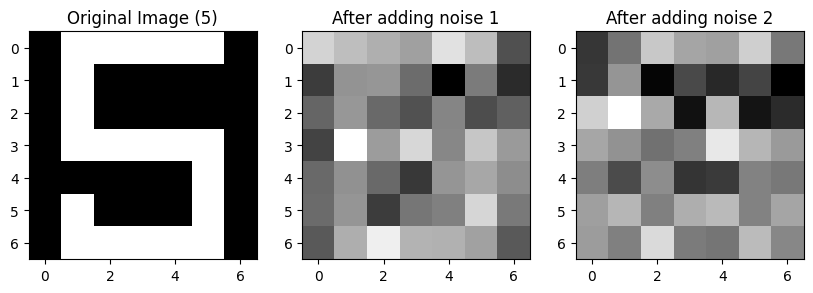

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np
import os

image = torch.tensor([
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0]
], dtype=torch.float32)

num_steps = 3
timesteps = torch.linspace(0, 1, num_steps)
def noising_process(x0, t):
    noise = torch.randn_like(x0) * t
    return x0 + noise

noisy_images = [noising_process(image, t) for t in timesteps]

print(len(noisy_images))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, noisy_img in enumerate(noisy_images):
    if i == 0:
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title("Original Image (5)")
    else:
        axes[i].imshow(noisy_img, cmap='gray')
        axes[i].set_title(f"After adding noise {i}")
plt.show()

In [37]:
timesteps

tensor([0.0000, 0.5000, 1.0000])

In [38]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = UNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
num_epochs = 500
for epoch in range(num_epochs):
    t = torch.rand(1) 
    noisy_image = noising_process(image, t).unsqueeze(0).unsqueeze(0)
    clean_image = image.unsqueeze(0).unsqueeze(0)

    optimizer.zero_grad()
    output = model(noisy_image)
    loss = criterion(output, noisy_image)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [0/500], Loss: 0.7167
Epoch [100/500], Loss: 0.0317
Epoch [200/500], Loss: 0.0734
Epoch [300/500], Loss: 0.0140
Epoch [400/500], Loss: 0.0057


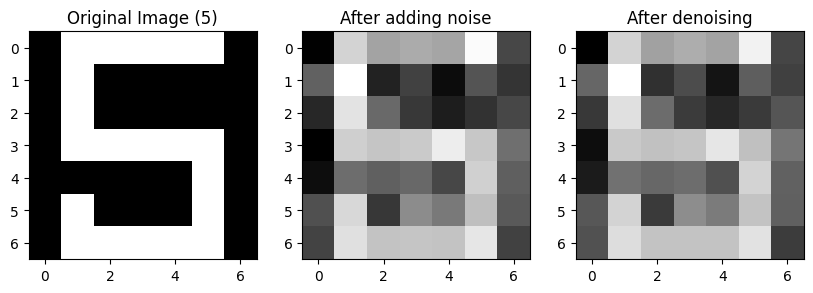

In [39]:
noisy_test = noising_process(image, torch.tensor(0.2)).unsqueeze(0).unsqueeze(0)
denoised_output = model(noisy_test).squeeze().detach()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image (5)")
axes[1].imshow(noisy_test.squeeze(), cmap='gray')
axes[1].set_title("After adding noise")
axes[2].imshow(denoised_output, cmap='gray')
axes[2].set_title("After denoising")
plt.show()

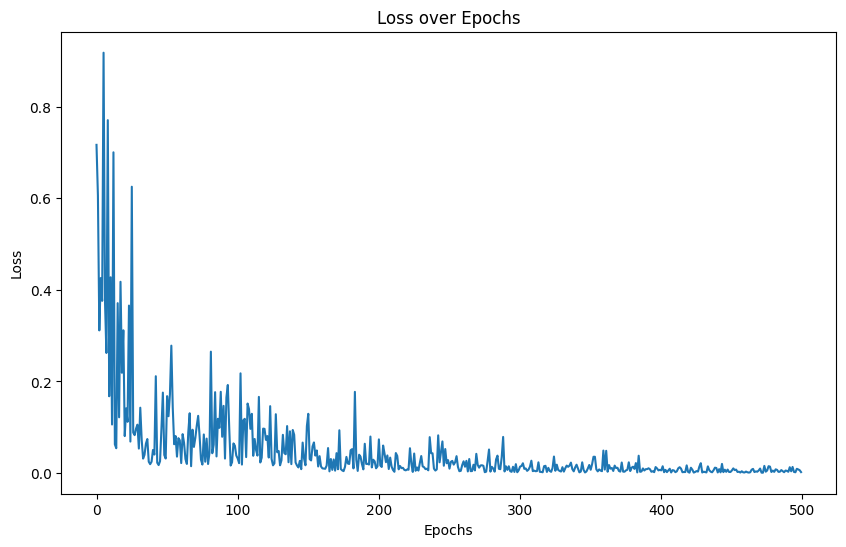

In [40]:
# Plot loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Diffusion Model

In [41]:
def sinusoidal_embedding(t, dim):
    if isinstance(t, int): 
        t = torch.tensor([t], dtype=torch.float32)

    half_dim = dim // 2
    emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)  # [half_dim]

    emb = t.unsqueeze(0) * emb.unsqueeze(0)  # [1] x [half_dim] -> [1, half_dim]
    emb = torch.cat([emb.sin(), emb.cos()], dim=-1)  # [1, dim]

    return emb


class SmallUNet(nn.Module):
    def __init__(self, input_channels, output_channels, T, hidden_dim=64):
        super().__init__()
        self.time_embed = sinusoidal_embedding(T, hidden_dim)

        # Encoder
        self.conv1 = nn.Conv2d(input_channels, hidden_dim//2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim//2, hidden_dim, kernel_size=3, padding=1)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(hidden_dim + hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim*2, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(hidden_dim*2, hidden_dim, kernel_size=3, padding=1)
        self.upconv2 = nn.ConvTranspose2d(hidden_dim, hidden_dim//2, kernel_size=3, padding=1)

        # Output
        self.mu_conv = nn.Conv2d(hidden_dim//2, output_channels, kernel_size=3, padding=1)
        self.sigma_conv = nn.Conv2d(hidden_dim//2, output_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        batch_size = x.shape[0]

        t_emb = self.time_embed.to(x.device)
        t_emb = t_emb.view(1, -1, 1, 1).expand(batch_size, -1, x.shape[2], x.shape[3])

        # Encoder
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))

        x_t = torch.cat([x2, t_emb], dim=1)

        # Bottleneck
        x_bottleneck = self.bottleneck(x_t)

        # Decoder
        x_up1 = torch.relu(self.upconv1(x_bottleneck))
        x_up2 = torch.relu(self.upconv2(x_up1))

        # Output
        mu = self.mu_conv(x_up2)
        sigma = torch.exp(self.sigma_conv(x_up2)).clamp(min=1e-5, max=1e5)

        return mu, sigma

class DiffusionModel():
    def __init__(self, T, model: nn.Module, device, dim=2):
        self.betas = (torch.sigmoid(torch.linspace(-17, 10, T)) * (3e-1 - 1e-5) + 1e-5).to(device)
        self.alphas = 1 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, 0)
        self.T = T
        self.model = model
        self.dim = dim
        self.device = device

    def forward_process(self, x0, t):
        """
        :param t: Number of diffusion steps
        """
        assert 1 <= t <= self.T, f't should be in range [1, {self.T}]'

        t = t.to(self.device)
        t_idx = t - 1  # index 0->t-1
        mu = torch.sqrt(self.alphas_bar[t_idx]) * x0
        std = torch.sqrt(1 - self.alphas_bar[t_idx])
        epsilon = torch.randn_like(x0)
        xt = mu + epsilon * std # Reparameterization trick

        std_q = torch.sqrt((1 - self.alphas_bar[t_idx-1])/ (1 - self.alphas_bar[t_idx]) * self.betas[t_idx])
        m1 = torch.sqrt(self.alphas_bar[t_idx-1]) * self.betas[t_idx] / (1 - self.alphas_bar[t_idx])
        m2 = torch.sqrt(self.alphas[t_idx]) * (1 - self.alphas_bar[t_idx-1]) / (1 - self.alphas_bar[t_idx])
        mu_q = m1 * x0 + m2 * xt

        return mu_q, std_q, xt

    def reverse_process(self, xt, t):
        """
        :param t: Number of diffusion steps
        """
        assert 1 <= t <= self.T, f't should be in range [1, {self.T}]'

        t = torch.tensor([t-1], device=self.device)

        mu, std = self.model(xt, t)
        epsilon = torch.randn_like(xt)
        return mu, std, mu + epsilon * std  # image denosing ~ N(mu, std)

    def sample(self, batch_size, device):
        noise = torch.randn((batch_size, *self.dim)).to(device)
        x = noise
        samples = [x]
        for t in range(self.T, 0, -1):
            mu, std, x_new = self.reverse_process(x, t)
            x = x_new
            samples.append(x)
        return samples

    def get_loss(self, x0):
        """
        :param x0: batch [batch_size, ...]
        """
        t = torch.randint(2, self.T+1, (1,), device=self.device)
        mu_q, sigma_q, xt = self.forward_process(x0, t)
        mu_p, sigma_p, _ = self.reverse_process(xt.float(), t.item())

        epsilon = 1e-8
        KL = torch.log(sigma_p + epsilon) - torch.log(sigma_q + epsilon) + (sigma_q**2 + (mu_q - mu_p)**2) / (2 * (sigma_p**2 + epsilon))
        K = - KL.mean()  # Should be maximized
        loss = - K  # Should be minimized
        return loss

    def save_model(self, path):
        torch.save({'model_state_dict': self.model.state_dict()}, path)

    def load_model(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])

# Train

In [42]:
os.makedirs('models', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

T = 4  
hidden_dim = 64
epochs = 6000

image_5 = np.array([
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0]
], dtype=np.float32)

image_tensor = torch.from_numpy(image_5).unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, 7, 7]

model = SmallUNet(input_channels=1, output_channels=1, T=T, hidden_dim=hidden_dim).to(device)
diffusion = DiffusionModel(T, model, device, dim=(1, 7, 7)) 

optimizer = optim.Adam(model.parameters(), lr=1e-4)

best_loss = float('inf')
losses = []
no_improve_count = 0

for epoch in range(epochs):
    x_batch = image_tensor.to(device)

    optimizer.zero_grad()
    loss = diffusion.get_loss(x_batch)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_val = loss.item()
    losses.append(loss_val)

    if loss_val < best_loss:
        best_loss = loss_val
        diffusion.save_model(f'models/best_diffusion_model.pth')
        print(f"New best model saved at epoch {epoch+1} with loss: {best_loss:.4f}")

print("Finished training!")

New best model saved at epoch 1 with loss: 1.2354
New best model saved at epoch 6 with loss: 1.2127
New best model saved at epoch 7 with loss: 1.1776
New best model saved at epoch 12 with loss: 1.1397
New best model saved at epoch 17 with loss: 1.1157
New best model saved at epoch 33 with loss: 1.0833
New best model saved at epoch 38 with loss: 1.0445
New best model saved at epoch 49 with loss: 0.9806
New best model saved at epoch 54 with loss: 0.9354
New best model saved at epoch 63 with loss: 0.8117
New best model saved at epoch 702 with loss: 0.7433
New best model saved at epoch 822 with loss: 0.6705
New best model saved at epoch 1067 with loss: 0.6238
New best model saved at epoch 1266 with loss: 0.6209
New best model saved at epoch 1370 with loss: 0.6076
New best model saved at epoch 1624 with loss: 0.5911
New best model saved at epoch 1627 with loss: 0.5883
New best model saved at epoch 1734 with loss: 0.5720
New best model saved at epoch 2049 with loss: 0.5703
New best model sav

# Visualize

Loading best model...
4


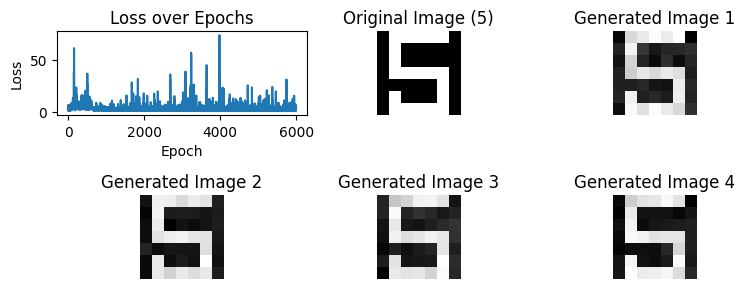

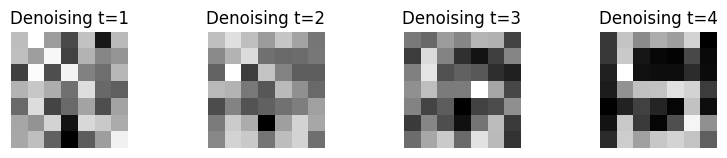

In [43]:
print("Loading best model...")
best_model = SmallUNet(input_channels=1, output_channels=1, T=T, hidden_dim=hidden_dim).to(device)
best_diffusion = DiffusionModel(T, best_model, device, dim=(1, 7, 7))
best_diffusion.load_model('models/best_diffusion_model.pth')

def test_model(diffusion_model, image_shape, num_samples=4):
    with torch.no_grad():
        diffusion_model.model.eval()
        samples = diffusion_model.sample(num_samples, device)
        final_samples = samples[-1].cpu()
        print(len(final_samples))

    plt.figure(figsize=(8, 3))

    plt.subplot(2, 3, 1)
    plt.plot(losses)
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(2, 3, 2)
    plt.imshow(image_5, cmap='gray')
    plt.title('Original Image (5)')
    plt.axis('off')

    for i in range(num_samples):
        plt.subplot(2, 3, i+3)
        plt.imshow(final_samples[i, 0].numpy(), cmap='gray')
        plt.title(f'Generated Image {i+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('best_model_results.png')
    plt.show()

    plt.figure(figsize=(8, 3))
    steps = np.arange(diffusion_model.T) 
    for i, step in enumerate(steps):
        plt.subplot(2, 4, i+1)
        sample = samples[step][0, 0].cpu().numpy()
        plt.imshow(sample, cmap='gray')
        plt.title(f'Denoising t={step+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('best_model_diffusion_process.png')
    plt.show()

test_model(best_diffusion, (1, 7, 7))

4


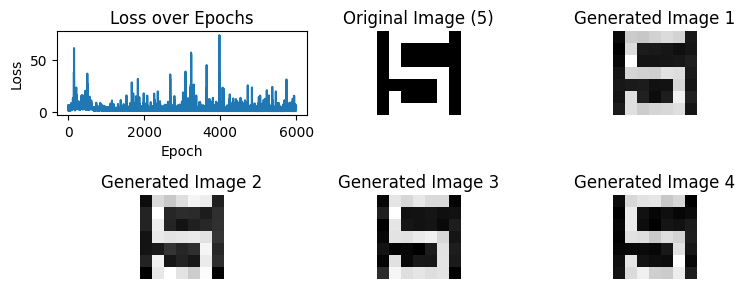

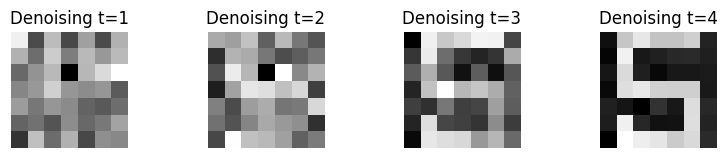

In [ ]:
test_model(best_diffusion, (1, 7, 7))

# Forward

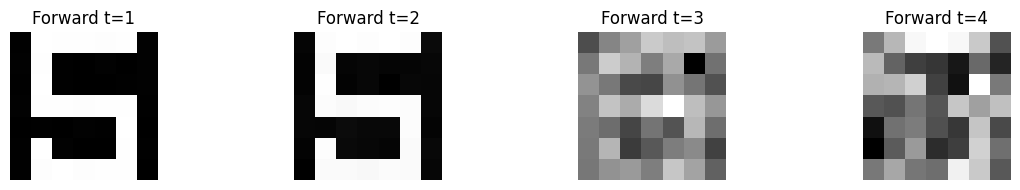

In [45]:
import torch
import matplotlib.pyplot as plt

def visualize_forward_process(diffusion_model, x0, t=10):
    device = diffusion_model.device
    x0 = x0.to(device)

    # Forward process
    forward_steps = []
    xt = x0
    for i in range(1, t+1):
        mu_q, std_q, xt = diffusion_model.forward_process(x0, torch.tensor(i, device=device))
        forward_steps.append(xt.cpu().numpy())

    fig, axes = plt.subplots(1, t, figsize=(t*3, 2))

    for i in range(t):
        axes[i].imshow(forward_steps[i][0, 0], cmap='gray')
        axes[i].set_title(f'Forward t={i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_forward_process(best_diffusion, image_tensor, t=4)


# Output forward ---> Reserve

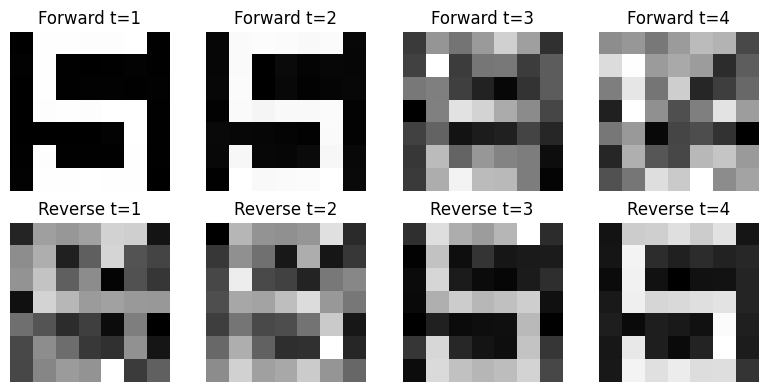

In [46]:
def visualize_forward_reverse_process(diffusion_model, x0, t=10):
    device = diffusion_model.device
    x0 = x0.to(device)

    # Forward process
    forward_steps = []
    xt = x0
    for i in range(1, t+1):
        mu_q, std_q, xt = diffusion_model.forward_process(x0, torch.tensor(i, device=device))
        forward_steps.append(xt.cpu().numpy())

    # Reverse process
    reverse_steps = []
    xt_reverse = xt  
    for i in range(t, 0, -1):
        mu_p, sigma_p, xt_reverse = diffusion_model.reverse_process(xt_reverse, i)
        reverse_steps.append(xt_reverse.detach().cpu().numpy())

    fig, axes = plt.subplots(2, t, figsize=(t*2, 4))

    for i in range(t):
        axes[0, i].imshow(forward_steps[i][0, 0], cmap='gray')
        axes[0, i].set_title(f'Forward t={i+1}')
        axes[0, i].axis('off')

    for i in range(t):
        axes[1, i].imshow(reverse_steps[i][0, 0], cmap='gray')
        axes[1, i].set_title(f'Reverse t={i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('forward_reverse_process.png')
    plt.show()


visualize_forward_reverse_process(best_diffusion, image_tensor, t=4)


# Random noisy ---> Reverse

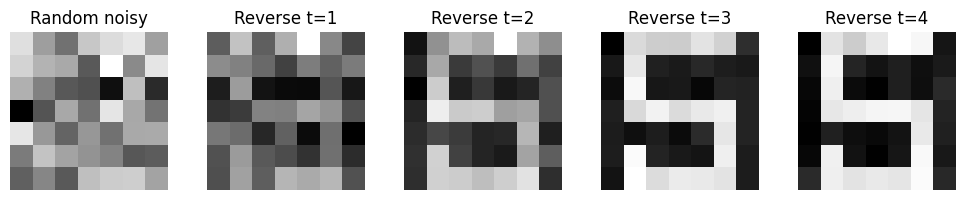

In [47]:
def visualize_reverse_process(diffusion_model, t=4):
    """
    Hiển thị quá trình reverse process từ noise.
    """
    device = diffusion_model.device

    xt_reverse = torch.randn((1, 1, 7, 7), device=device)  


    # Reverse process
    reverse_steps = [xt_reverse.cpu().numpy()]
    for i in range(t, 0, -1):
        mu_p, sigma_p, xt_reverse = diffusion_model.reverse_process(xt_reverse, i)
        reverse_steps.append(xt_reverse.detach().cpu().numpy())

    fig, axes = plt.subplots(1, t+1, figsize=((t+1)*2, 2))

    for i in range(t+1):
        if i == 0:
            axes[i].imshow(reverse_steps[i][0, 0], cmap='gray')
            axes[i].set_title(f'Random noisy')
            axes[i].axis('off')
        else:
            axes[i].imshow(reverse_steps[i][0, 0], cmap='gray')
            axes[i].set_title(f'Reverse t={i}')
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('reverse_process.png')
    plt.show()
visualize_reverse_process(best_diffusion, t=4)